In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
churn_labels = pd.read_csv("../data/churn_labels.csv")

print("Customers Shape:", customers.shape)
print("Orders Shape:", orders.shape)
print("Churn Labels Shape:", churn_labels.shape)

Customers Shape: (2400, 9)
Orders Shape: (10009, 10)
Churn Labels Shape: (2400, 4)


In [3]:
orders_summary = orders.groupby("customer_id").agg({
    "order_id": "count",
    "gross_amount": "sum",
    "rating": "mean"
}).reset_index()

orders_summary.columns = [
    "customer_id",
    "total_orders",
    "total_spend",
    "avg_rating"
]

orders_summary.head()

,customer_id,total_orders,total_spend,avg_rating
0,CUST00001,6,2955.57,3.333333
1,CUST00002,3,1713.10,4.333333
2,CUST00003,1,649.98,2.000000
3,CUST00004,1,1604.04,2.000000
4,CUST00005,6,3910.43,2.333333


In [4]:
model_data = customers.merge(
    orders_summary,
    on="customer_id",
    how="left"
)

model_data = model_data.merge(
    churn_labels,
    on="customer_id",
    how="left"
)

print(model_data.shape)

(2400, 15)


In [5]:
model_data["avg_rating"] = model_data["avg_rating"].fillna(
    model_data["avg_rating"].mean()
)

model_data["total_orders"] = model_data["total_orders"].fillna(0)

model_data["total_spend"] = model_data["total_spend"].fillna(0)

model_data.isnull().sum()

customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
total_orders              0
total_spend               0
avg_rating                0
snapshot_date             0
churn_next_60d            0
split                     0
dtype: int64

In [6]:
features = model_data[
    ["total_orders", "total_spend", "avg_rating"]
]

target = model_data["churn_next_60d"]

print(features.head())

   total_orders  total_spend  avg_rating
0             6      2955.57    3.333333
1             3      1713.10    4.333333
2             1       649.98    2.000000
3             1      1604.04    2.000000
4             6      3910.43    2.333333


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1920, 3)
(480, 3)


In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [9]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.6458333333333334


In [10]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.6458333333333334


In [11]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.66      0.71      0.69       259
           1       0.63      0.57      0.60       221

    accuracy                           0.65       480
   macro avg       0.64      0.64      0.64       480
weighted avg       0.64      0.65      0.64       480



In [12]:
feature_importance = pd.DataFrame({
    "Feature": features.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,total_spend,0.686186
0,total_orders,0.173183
2,avg_rating,0.140631


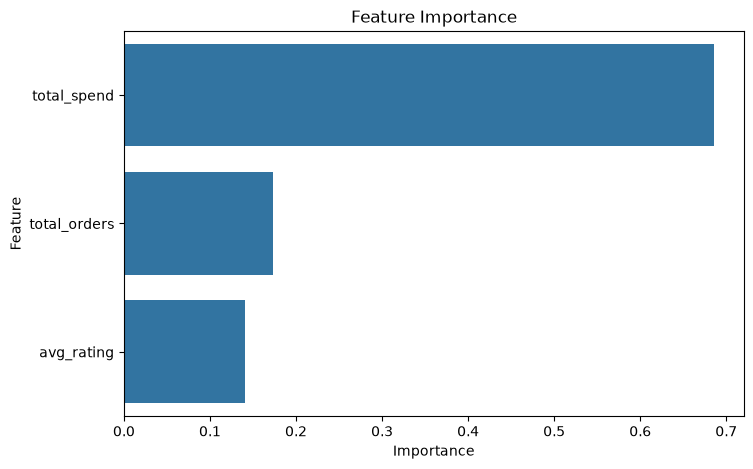

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [14]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature Importance Saved")

Feature Importance Saved


In [15]:
predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

predictions_df.to_csv(
    "predictions.csv",
    index=False
)

print("Predictions Saved")

Predictions Saved


In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy:
0.65625


In [17]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))


Accuracy: 0.6458333333333334
Precision: 0.628140703517588
Recall: 0.5656108597285068
F1 Score: 0.5952380952380952


In [18]:
from sklearn.metrics import roc_auc_score

rf_prob = model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, rf_prob)

print("ROC AUC:", roc_auc)


ROC AUC: 0.7023270846800259


In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[185  74]
 [ 96 125]]


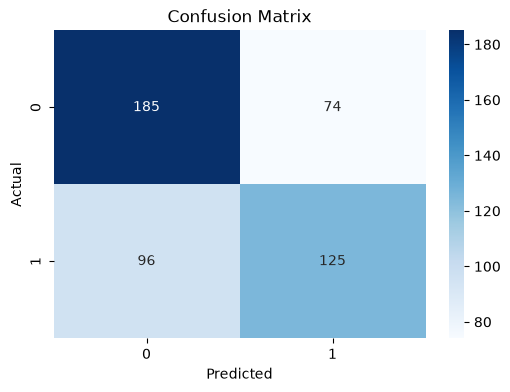

In [20]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [21]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved")

Model Saved


In [22]:
import json

metrics = {
    "accuracy": 0.6458,
    "precision": 0.6281,
    "recall": 0.5656,
    "f1_score": 0.5952,
    "roc_auc": 0.7023
}

with open("metrics.json", "w") as file:
    json.dump(metrics, file, indent=4)

print("Metrics Saved")

Metrics Saved
